**NAME: SAIRA JABEEN, ROLL NO:23-AI-10, SECTION: A2(B), TASK 01 (PLANT VILLAGE)**

In [1]:
import os
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

!pip install kaggle -q
!kaggle datasets download -d emmarex/plantdisease --unzip -p /content/PlantVillage
print("Done!")

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:06<00:00, 99.8MB/s]

Done!


In [2]:
import os

print(os.listdir())  # check folders

['.config', 'PlantVillage', 'sample_data']


In [3]:
data_path = "PlantVillage/PlantVillage"   # MOST IMPORTANT FIX

print("Classes:", os.listdir(data_path)[:5])

Classes: ['Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Pepper__bell___Bacterial_spot', 'Tomato__Tomato_mosaic_virus', 'Tomato_Late_blight']


In [4]:
import os

count = 0

for root, dirs, files in os.walk("/content/PlantVillage"):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            count += 1

print("Total images:", count)

Total images: 41276


In [5]:
import os

# Select first folder (class label)
folder = os.listdir(data_path)[0]

# Select first image inside that folder
img_name = os.listdir(os.path.join(data_path, folder))[0]

# Create full image path
sample_path = os.path.join(data_path, folder, img_name)

# Print path to verify
print(sample_path)

PlantVillage/PlantVillage/Tomato__Target_Spot/942dbcb4-7c9e-4ec7-beea-cd11383c7d83___Com.G_TgS_FL 0835.JPG


In [6]:
import cv2
import numpy as np

IMG_SIZE = 64

def preprocess_image(img_path):
    img = cv2.imread(img_path)

    if img is None:
        return None

    # Resize image
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply histogram equalization
    equalized = cv2.equalizeHist(gray)

    return equalized

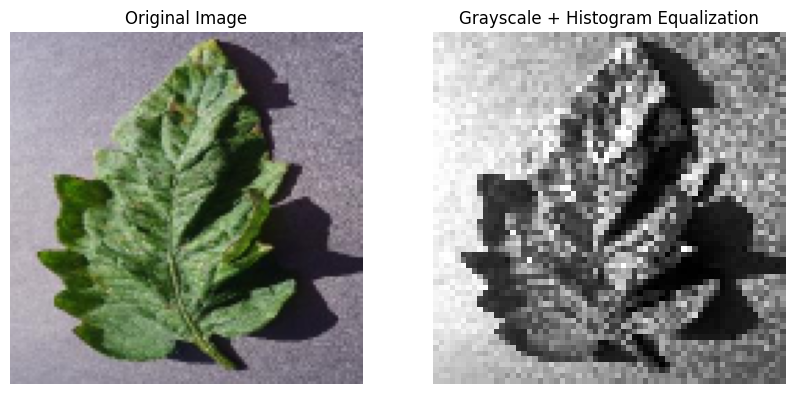

In [7]:
import cv2
import matplotlib.pyplot as plt

# Read original image
img_original = cv2.imread(sample_path)

# Resize image to fixed size
img_original = cv2.resize(img_original, (128,128))

# Apply preprocessing (grayscale + histogram equalization)
img_processed = preprocess_image(sample_path)

# Create comparison plot
plt.figure(figsize=(10,5))

# Show original image
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

# Show processed grayscale image
plt.subplot(1,2,2)
plt.imshow(img_processed, cmap='gray')
plt.title("Grayscale + Histogram Equalization")
plt.axis('off')

# Display plots
plt.show()

In [8]:
import cv2
import numpy as np

def apply_filters(img):
    # Sobel filter in X direction (detects vertical edges)
    sobelx = cv2.filter2D(img, -1, np.array([[1,0,-1],
                                              [2,0,-2],
                                              [1,0,-1]]))

    # Sobel filter in Y direction (detects horizontal edges)
    sobely = cv2.filter2D(img, -1, np.array([[1,2,1],
                                              [0,0,0],
                                              [-1,-2,-1]]))

    # Laplacian filter (detects all edges)
    laplacian = cv2.filter2D(img, -1, np.array([[0,1,0],
                                                 [1,-4,1],
                                                 [0,1,0]]))

    return sobelx, sobely, laplacian

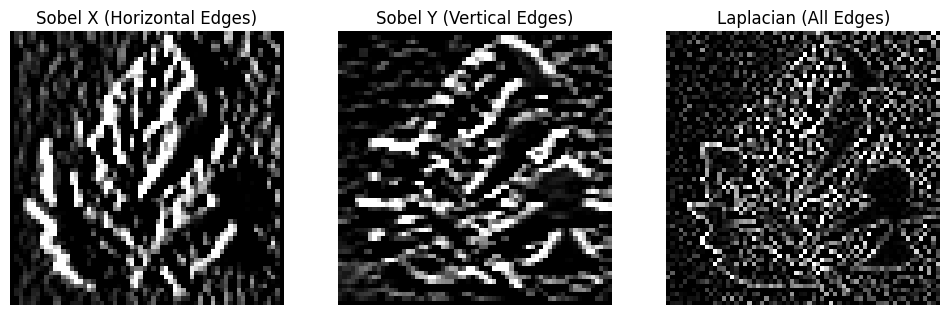

In [9]:
# Apply filters
sobelx, sobely, laplacian = apply_filters(img_processed)

# Plot results
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(sobelx, cmap='gray')
plt.title("Sobel X (Horizontal Edges)")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(sobely, cmap='gray')
plt.title("Sobel Y (Vertical Edges)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(laplacian, cmap='gray')
plt.title("Laplacian (All Edges)")
plt.axis('off')

plt.show()

In [10]:
from tqdm import tqdm

X = []
y = []
labels = {}

label_id = 0

for folder in os.listdir(data_path):
    folder_path = os.path.join(data_path, folder)

    if not os.path.isdir(folder_path):
        continue

    labels[label_id] = folder

    for img_name in tqdm(os.listdir(folder_path)):
        img_path = os.path.join(folder_path, img_name)

        img = preprocess_image(img_path)
        if img is not None:
            X.append(img)
            y.append(label_id)

    label_id += 1

X = np.array(X)
y = np.array(y)

print("Data Loaded:", X.shape)

100%|██████████| 1478/1478 [00:00<00:00, 1558.33it/s]

Data Loaded: (20638, 64, 64)


In [12]:
X = X / 255.0
X = X.reshape(-1, 64, 64, 1)

print(X.shape)

(20638, 64, 64, 1)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)

(16510, 64, 64, 1)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model_fc = Sequential([
    Flatten(input_shape=(64,64,1)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(len(labels), activation='softmax')
])

model_fc.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fc = model_fc.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.1943 - loss: 2.4503 - val_accuracy: 0.2541 - val_loss: 2.2749
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.3096 - loss: 2.1422 - val_accuracy: 0.3702 - val_loss: 2.0191
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.3761 - loss: 1.9558 - val_accuracy: 0.3968 - val_loss: 1.8984
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4012 - loss: 1.8669 - val_accuracy: 0.4031 - val_loss: 1.8588
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4177 - loss: 1.8106 - val_accuracy: 0.4210 - val_loss: 1.7863
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.4313 - loss: 1.7649 - val_accuracy: 0.4314 - val_loss: 1.7846
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4460 - loss: 1.7208 - val_accuracy: 0.4453 - val_loss: 1.7209
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4568 - loss: 1.6824 - val_accurac

In [16]:
history_fc = model_fc.fit(
    X_train, y_train,
    epochs=10,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.4816 - loss: 1.6050 - val_accuracy: 0.4826 - val_loss: 1.6158
Epoch 2/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.4923 - loss: 1.5638 - val_accuracy: 0.4794 - val_loss: 1.6171
Epoch 3/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5037 - loss: 1.5346 - val_accuracy: 0.4976 - val_loss: 1.5775
Epoch 4/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.5105 - loss: 1.5074 - val_accuracy: 0.4981 - val_loss: 1.5509
Epoch 5/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.5197 - loss: 1.4834 - val_accuracy: 0.4961 - val_loss: 1.5494
Epoch 6/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5254 - loss: 1.4615 - val_accuracy: 0.5068 - val_loss: 1.5288
Epoch 7/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.5355 - loss: 1.4367 - val_accuracy: 0.5194 - val_loss: 1.5108
Epoch 8/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.5411 - loss: 1.4124 - 

In [17]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [18]:
X_rgb = np.repeat(X, 3, axis=-1)

In [20]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(64,64,3)
)

for layer in base_model.layers:
    layer.trainable = False

/tmp/ipykernel_3224/506340646.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [22]:
from tensorflow.keras.layers import Dropout
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(labels), activation='softmax')(x)

model_tl = Model(inputs=base_model.input, outputs=output)

In [23]:
model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2
)

history_tl = model_tl.fit(
    X_rgb, y,
    epochs=5,
    validation_split=0.2,
    callbacks=[lr_scheduler]
)

Epoch 1/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 75s 136ms/step - accuracy: 0.1730 - loss: 2.4612 - val_accuracy: 0.0000e+00 - val_loss: 5.3287 - learning_rate: 0.0010
Epoch 2/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 81s 157ms/step - accuracy: 0.2070 - loss: 2.3109 - val_accuracy: 0.0000e+00 - val_loss: 6.4860 - learning_rate: 0.0010
Epoch 3/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 70s 136ms/step - accuracy: 0.2232 - loss: 2.2728 - val_accuracy: 0.0000e+00 - val_loss: 5.4081 - learning_rate: 0.0010
Epoch 4/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 77s 149ms/step - accuracy: 0.2291 - loss: 2.2403 - val_accuracy: 0.0000e+00 - val_loss: 6.0984 - learning_rate: 3.0000e-04
Epoch 5/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 77s 150ms/step - accuracy: 0.2323 - loss: 2.2338 - val_accuracy: 0.0000e+00 - val_loss: 6.5034 - learning_rate: 3.0000e-04


In [24]:
for layer in base_model.layers[-20:]:
    layer.trainable = True

model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model_tl.fit(
    X_rgb, y,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 134s 222ms/step - accuracy: 0.3275 - loss: 2.0107 - val_accuracy: 0.0000e+00 - val_loss: 40.2580
Epoch 2/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 118s 229ms/step - accuracy: 0.4066 - loss: 1.7794 - val_accuracy: 0.0000e+00 - val_loss: 36.9559
Epoch 3/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 124s 240ms/step - accuracy: 0.4491 - loss: 1.6567 - val_accuracy: 0.0000e+00 - val_loss: 13.7939
Epoch 4/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 118s 229ms/step - accuracy: 0.4740 - loss: 1.5775 - val_accuracy: 0.0000e+00 - val_loss: 47.1760
Epoch 5/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 135s 216ms/step - accuracy: 0.4965 - loss: 1.5154 - val_accuracy: 0.0000e+00 - val_loss: 42.6599


In [26]:
# Evaluation
print("CNN Accuracy:")
model_fc.evaluate(X_test, y_test)

print("FC Accuracy:")
model_fc.evaluate(X_test, y_test)

CNN Accuracy:
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5104 - loss: 1.5124
FC Accuracy:
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5104 - loss: 1.5124


[1.512431263923645, 0.5104166865348816]